In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [121]:
data = pd.read_csv(r"C:\Users\Leo Samuel Gilbert\Downloads\Bird_Migration_Data_with_Origin.csv")
data.head()

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Yes,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264"
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Yes,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978"
2,B1002,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,19.448466,...,No,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High,"87.86116387126651, -78.72732718179907"
3,B1003,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,...,Yes,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318"
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966"


In [103]:
data.shape

(10000, 42)

In [104]:
data.columns


Index(['Bird_ID', 'Species', 'Region', 'Habitat', 'Weather_Condition',
       'Migration_Reason', 'Start_Latitude', 'Start_Longitude', 'End_Latitude',
       'End_Longitude', 'Flight_Distance_km', 'Flight_Duration_hours',
       'Average_Speed_kmph', 'Max_Altitude_m', 'Min_Altitude_m',
       'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Pressure_hPa',
       'Visibility_km', 'Nesting_Success', 'Tag_Battery_Level_%',
       'Signal_Strength_dB', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Tag_Type', 'Migrated_in_Flock',
       'Flock_Size', 'Food_Supply_Level', 'Tracking_Quality',
       'Migration_Interrupted', 'Interrupted_Reason', 'Tagged_By',
       'Tag_Weight_g', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Observation_Counts', 'Observation_Quality',
       'Origin'],
      dtype='object')

In [93]:
data['Signal_Strength_dB']

0      -64.9
1      -68.0
2      -71.9
3      -70.2
4      -50.5
        ... 
9995   -82.1
9996   -86.0
9997   -65.9
9998   -52.6
9999   -66.0
Name: Signal_Strength_dB, Length: 10000, dtype: float64

## Data Cleaning

#### Dropping irrelevant columns 

In [122]:
data = data.drop(['Bird_ID','Tagged_By','Tag_Weight_g','Tag_Type','Signal_Strength_dB','Observation_Counts','Observation_Quality'],axis=1)

In [123]:
data.shape

(10000, 35)

## Handling Missing values 



In [111]:
print("Missing Values Before Cleaning:")
print(data.isnull().sum())

Missing Values Before Cleaning:
Bird_ID                       0
Species                       0
Region                        0
Habitat                       0
Weather_Condition             0
Migration_Reason              0
Start_Latitude                0
Start_Longitude               0
End_Latitude                  0
End_Longitude                 0
Flight_Distance_km            0
Flight_Duration_hours         0
Average_Speed_kmph            0
Max_Altitude_m                0
Min_Altitude_m                0
Temperature_C                 0
Wind_Speed_kmph               0
Humidity_%                    0
Pressure_hPa                  0
Visibility_km                 0
Nesting_Success               0
Tag_Battery_Level_%           0
Signal_Strength_dB            0
Migration_Start_Month         0
Migration_End_Month           0
Rest_Stops                    0
Predator_Sightings            0
Tag_Type                      0
Migrated_in_Flock             0
Flock_Size                    0
Food_Sup

In [110]:
#check for duplication
print(data.duplicated().sum())

0


In [114]:
# Z-Score Method for outlier detection 
from scipy import stats

# Selecting numeric columns only
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Calculating Z-scores
z_scores = np.abs(stats.zscore(data[numeric_cols]))

# Outliers where z > 3
outliers_zscore = np.where(z_scores > 3)
print("Outliers detected using Z-score method:", len(outliers_zscore[0]))

# IQR Method
outliers_iqr = {}
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    outliers_iqr[col] = outliers.shape[0]

print("Outliers detected using IQR method per column:")
for col, count in outliers_iqr.items():
    print(f"{col}: {count}")


Outliers detected using Z-score method: 0
Outliers detected using IQR method per column:
Start_Latitude: 0
Start_Longitude: 0
End_Latitude: 0
End_Longitude: 0
Flight_Distance_km: 0
Flight_Duration_hours: 0
Average_Speed_kmph: 0
Max_Altitude_m: 0
Min_Altitude_m: 0
Temperature_C: 0
Wind_Speed_kmph: 0
Humidity_%: 0
Pressure_hPa: 0
Visibility_km: 0
Tag_Battery_Level_%: 0
Signal_Strength_dB: 0
Rest_Stops: 0
Predator_Sightings: 0
Flock_Size: 0
Tag_Weight_g: 0
Recovery_Time_days: 0
Observation_Counts: 0


DATA TYPE CONVERSIONS

In [124]:
print("Before Conversion:\n", data.dtypes)


Before Conversion:
 Species                     object
Region                      object
Habitat                     object
Weather_Condition           object
Migration_Reason            object
Start_Latitude             float64
Start_Longitude            float64
End_Latitude               float64
End_Longitude              float64
Flight_Distance_km         float64
Flight_Duration_hours      float64
Average_Speed_kmph         float64
Max_Altitude_m               int64
Min_Altitude_m               int64
Temperature_C              float64
Wind_Speed_kmph            float64
Humidity_%                   int64
Pressure_hPa               float64
Visibility_km              float64
Nesting_Success             object
Tag_Battery_Level_%          int64
Migration_Start_Month       object
Migration_End_Month         object
Rest_Stops                   int64
Predator_Sightings           int64
Migrated_in_Flock           object
Flock_Size                   int64
Food_Supply_Level           object


In [129]:
# Convert categorical columns to 'category' type
categorical_cols = ['Species', 'Region', 'Habitat', 'Weather_Condition', 
                    'Migration_Reason', 'Nesting_Success', 
                    'Migration_Start_Month', 'Migration_End_Month', 
                     'Origin']

for col in categorical_cols:
    data[col] = data[col].astype('category')


print(data.dtypes)


Species                    category
Region                     category
Habitat                    category
Weather_Condition          category
Migration_Reason           category
Start_Latitude              float64
Start_Longitude             float64
End_Latitude                float64
End_Longitude               float64
Flight_Distance_km          float64
Flight_Duration_hours       float64
Average_Speed_kmph          float64
Max_Altitude_m                int64
Min_Altitude_m                int64
Temperature_C               float64
Wind_Speed_kmph             float64
Humidity_%                    int64
Pressure_hPa                float64
Visibility_km               float64
Nesting_Success            category
Tag_Battery_Level_%           int64
Migration_Start_Month      category
Migration_End_Month        category
Rest_Stops                    int64
Predator_Sightings            int64
Migrated_in_Flock            object
Flock_Size                    int64
Food_Supply_Level           

In [125]:
data['Migration_End_Month'].value_counts()

Migration_End_Month
Nov    1474
Apr    1461
Mar    1442
Dec    1438
Jun    1408
Oct    1393
May    1384
Name: count, dtype: int64

Encoding 

In [150]:
#mapping successful to 1 and failed to 0 
data['Migration_Success'] = data['Migration_Success'].map({'Successful': 1, 'Failed': 0})


print(data['Migration_Success'].value_counts())


Migration_Success
1    5094
0    4906
Name: count, dtype: int64


In [193]:
food_map = {'Low': 1, 'Medium': 2, 'High': 3}
data['Food_Supply_Num'] = data['Food_Supply_Level'].map(food_map)
data['Food_Supply_Num'].value_counts()


Food_Supply_Num
3    3412
1    3349
2    3239
Name: count, dtype: int64

In [208]:
flock_map = {
    'Solo (1)': 1,
    'Small (2–5)': 2,
    'Medium (6–15)': 3,
    'Large (16–30)': 4,
    'Very large (31+)': 5
}
data['Flock_Size_Num'] = data['Flock_Size_Band'].map(flock_map)

data['Flock_Size_Num'].value_counts()


Flock_Size_Num
5    9344
4     343
3     207
2      90
1      16
Name: count, dtype: int64

## OUTLIER DETECTION

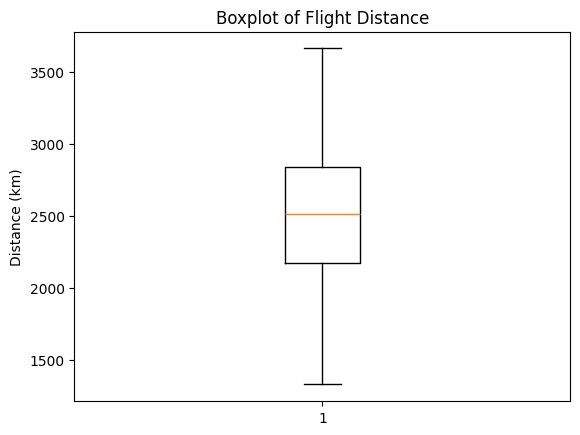

In [15]:
import matplotlib.pyplot as plt

plt.boxplot(data['Flight_Distance_km'])
plt.title("Boxplot of Flight Distance")
plt.ylabel("Distance (km)")
plt.show()


In [16]:
print("Minimum:", data['Flight_Distance_km'].min())
print("1st Percentile:", q_low)
print("99th Percentile:", q_high)
print("Maximum:", data['Flight_Distance_km'].max())


Minimum: 1328.6691
1st Percentile: 1328.6691
99th Percentile: 3662.968600000001
Maximum: 3662.968600000001


In [17]:
outliers = data[(data['Flight_Distance_km'] < q_low) | (data['Flight_Distance_km'] > q_high)]
print("Number of Outliers:", outliers.shape[0])
print(outliers[['Bird_ID', 'Flight_Distance_km']].head(10))  # show first 10 outliers

Number of Outliers: 0
Empty DataFrame
Columns: [Bird_ID, Flight_Distance_km]
Index: []


In [14]:
# Example: Cap Flight_Distance at 99th percentile
q_low, q_high = data['Flight_Distance_km'].quantile([0.01, 0.99])
data['Flight_Distance_km'] = np.where(data['Flight_Distance_km'] > q_high, q_high,
                                      np.where(data['Flight_Distance_km'] < q_low, q_low, data['Flight_Distance_km']))


## Automating outlier detection 

## Outlier detection

In [20]:
continuous_cols = [
    'Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m',
    'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
    'Humidity_%', 'Pressure_hPa', 'Visibility_km'
]

outlier_summary = {}

for col in continuous_cols:
    q_low, q_high = data[col].quantile([0.01, 0.99])
    outliers = data[(data[col] < q_low) | (data[col] > q_high)]
    outlier_summary[col] = outliers.shape[0]

for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")



Flight_Distance_km: 200 outliers
Average_Speed_kmph: 200 outliers
Max_Altitude_m: 200 outliers
Min_Altitude_m: 184 outliers
Temperature_C: 169 outliers
Wind_Speed_kmph: 189 outliers
Humidity_%: 91 outliers
Pressure_hPa: 194 outliers
Visibility_km: 146 outliers


## Pivot 

In [8]:
features = list(data.columns)
print(features)

['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph', 'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success', 'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month', 'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size', 'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted', 'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known', 'Recovery_Time_days', 'Origin']


In [31]:
for feature in features:
    pivot = data.pivot_table(index=feature,aggfunc='size')
    feature_pivot_table_df = pivot.reset_index(name='count')
    display(feature_pivot_table_df)


,Species,count
0,Crane,1391
1,Eagle,1426
2,Goose,1428
3,Hawk,1464
4,Stork,1439
5,Swallow,1423
6,Warbler,1429


,Region,count
0,Africa,1669
1,Asia,1687
2,Australia,1633
3,Europe,1595
4,North America,1699
5,South America,1717


,Habitat,count
0,Coastal,1680
1,Forest,1663
2,Grassland,1637
3,Mountain,1647
4,Urban,1674
5,Wetland,1699


,Weather_Condition,count
0,Clear,1925
1,Foggy,2136
2,Rainy,1920
3,Stormy,2010
4,Windy,2009


,Migration_Reason,count
0,Avoid Predators,2518
1,Breeding,2436
2,Climate Change,2473
3,Feeding,2573


...

,Interrupted_Reason,count
0,Injury,2023
1,Lost Signal,1943
2,Predator,1994
3,Storm,2059


,Migration_Success,count
0,Failed,4906
1,Successful,5094


,Recovery_Location_Known,count
0,No,4987
1,Yes,5013


,Recovery_Time_days,count
0,1,72
1,2,79
2,3,91
3,4,96
4,5,96
...,...,...
114,115,76
115,116,101
116,117,87
117,118,68


,Origin,count
0,"-0.0246360838085593, -44.481967874536",1
1,"-0.0278168786031329, 103.9061494769548",1
2,"-0.0303925434602376, 150.0753051290214",1
3,"-0.0412250952710451, -149.01441256523626",1
4,"-0.0568340430333904, 88.35464134507367",1
...,...,...
9995,"9.978655988207151, 130.58278577615113",1
9996,"9.981135408373731, -32.20259364074798",1
9997,"9.984037931796962, -167.55310595319563",1
9998,"9.990531275726354, 128.2780781926882",1


## Binning 

In [130]:
#binning flight distance km to category 
bins = [0, 1000, 2000, 3000, float('inf')]
labels = ['Short', 'Medium', 'Long', 'Very Long']
data['Flight_Distance_Category'] = pd.cut(data['Flight_Distance_km'], bins=bins, labels=labels)

data['Flight_Distance_Category'].value_counts()


Flight_Distance_Category
Long         6857
Medium       1563
Very Long    1563
Short          17
Name: count, dtype: int64

In [131]:
speed_bins = [30.0, 40.0, 50.0, 60.0, 70.0,float('inf')]  # Bin edges
speed_labels = ['30-40 KMPH', '40-50 KMPH', '50-60 KMPH', '60-70 KMPH','70+ KMPH']
data['Speed_Category'] = pd.cut(data['Average_Speed_kmph'], bins=speed_bins, labels=speed_labels)

data['Speed_Category'].value_counts()

Speed_Category
50-60 KMPH    4785
40-50 KMPH    4708
30-40 KMPH     267
60-70 KMPH     240
70+ KMPH         0
Name: count, dtype: int64

In [132]:
altitude_bins = [0, 1000, 3000, 5000, float('inf')]
altitude_labels = ['Low', 'Medium', 'High', 'Very High']
data['Altitude_Category'] = pd.cut(data['Max_Altitude_m'], bins=altitude_bins, labels=altitude_labels)

data['Altitude_Category'].value_counts()

Altitude_Category
Very High    5616
Medium       2206
High         2174
Low             4
Name: count, dtype: int64

In [133]:
temp_bins = [-float('inf'), 0, 20, 35, float('inf')]
temp_labels = ['Cold', 'Moderate', 'Warm', 'Very Hot']
data['Temperature_Category'] = pd.cut(data['Temperature_C'], bins=temp_bins, labels=temp_labels)
data['Temperature_Category'].value_counts()


Temperature_Category
Moderate    4422
Warm        3347
Cold        2231
Very Hot       0
Name: count, dtype: int64

In [134]:
wind_bins = [0, 10, 30, 50, float('inf')]
wind_labels = ['Calm', 'Breezy', 'Windy', 'Very Windy']
data['Wind_Speed_Category'] = pd.cut(data['Wind_Speed_kmph'],bins=wind_bins,labels=wind_labels )
data['Wind_Speed_Category'].value_counts()

Wind_Speed_Category
Windy         3380
Breezy        3259
Very Windy    1707
Calm          1647
Name: count, dtype: int64

In [135]:
visibility_bins = [0, 5, 10, 20, float('inf')]
visibility_labels = ['Poor', 'Moderate', 'Good', 'Excellent']
data['Visibility_Category'] = pd.cut(data['Visibility_km'], bins=visibility_bins, labels=visibility_labels)
data['Visibility_Category'].value_counts()



Visibility_Category
Good         5357
Moderate     2566
Poor         2077
Excellent       0
Name: count, dtype: int64

In [136]:
humidity_bins = [0, 30, 60, 90, 100]
humidity_labels = ['Low', 'Moderate', 'High', 'Very High']
data['Humidity_Category'] = pd.cut(data['Humidity_%'], bins=humidity_bins, labels=humidity_labels)

data['Humidity_Category'].value_counts()

Humidity_Category
Moderate     3400
High         3301
Low          2344
Very High     955
Name: count, dtype: int64

In [170]:
bins   = [-np.inf, 1, 5, 15, 30, np.inf]
labels = ["Solo (1)", "Small (2–5)", "Medium (6–15)", "Large (16–30)", "Very large (31+)"]
data["Flock_Size_Band"] = pd.cut(data["Flock_Size"], bins=bins, labels=labels)

data["Flock_Size_Band"].value_counts()

Flock_Size_Band
Very large (31+)    9344
Large (16–30)        343
Medium (6–15)        207
Small (2–5)           90
Solo (1)              16
Name: count, dtype: int64

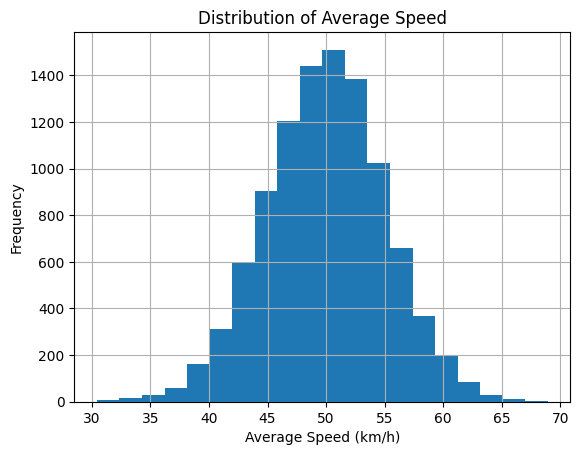

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns 
data['Average_Speed_kmph'].hist(bins=20)
plt.title('Distribution of Average Speed')
plt.xlabel('Average Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

In [33]:
data['Species'].value_counts()

Species
Hawk       1464
Stork      1439
Warbler    1429
Goose      1428
Eagle      1426
Swallow    1423
Crane      1391
Name: count, dtype: int64

# EDA 

Role of rest stops, predator sightings, flock size, food supply in migration success.

In [141]:
# Success rate by number of rest stops
success_by_rest = data.groupby("Rest_Stops")["Migration_Success"] \
                    .value_counts(normalize=True) \
                    .unstack()
print(success_by_rest)

Migration_Success    Failed  Successful
Rest_Stops                             
1                  0.486824    0.513176
2                  0.474761    0.525239
3                  0.466667    0.533333
4                  0.492497    0.507503
5                  0.447543    0.552457
6                  0.502104    0.497896
7                  0.485632    0.514368
8                  0.495702    0.504298
9                  0.462585    0.537415
10                 0.512126    0.487874
11                 0.523810    0.476190
12                 0.506006    0.493994
13                 0.505797    0.494203
14                 0.515988    0.484012


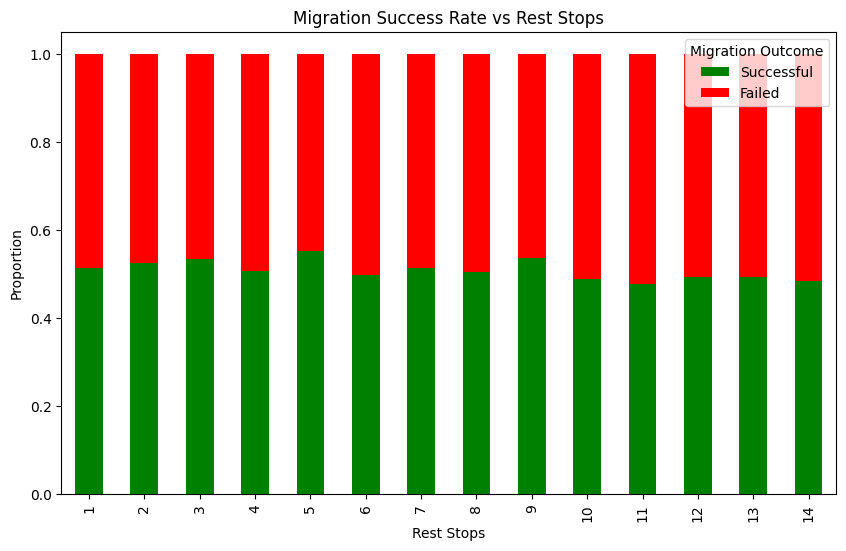

In [143]:
#visualisation 
success_by_rest[[ 'Successful', 'Failed']].plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['green','red']
)

plt.title("Migration Success Rate vs Rest Stops")
plt.xlabel("Rest Stops")
plt.ylabel("Proportion")
plt.legend(title="Migration Outcome")
plt.show()

In [168]:
# Predator sightings impact
success_by_predators = (
    data.groupby("Predator_Sightings")["Migration_Success"]
    .value_counts(normalize=True)
    .unstack()
    )

print("Proportions using Pandas GroupBy:")
print(success_by_predators)

Proportions using Pandas GroupBy:
Migration_Success          0         1
Predator_Sightings                    
0                   0.518049  0.481951
1                   0.454637  0.545363
2                   0.488488  0.511512
3                   0.483673  0.516327
4                   0.495976  0.504024
5                   0.478218  0.521782
6                   0.484699  0.515301
7                   0.505941  0.494059
8                   0.498492  0.501508
9                   0.496945  0.503055


In [160]:
predator_groups = data.groupby("Predator_Sightings")

success_rates_numpy = {
    f"Success rate when {k} predator{'s were' if k != 1 else ' was'} sighted": 
        np.mean(v["Migration_Success"].values) 
    for k, v in predator_groups
}

print("\nSuccess Rates using NumPy:")
for k, v in success_rates_numpy.items():
    print(f"{k}: {v:.2f}")



Success Rates using NumPy:
Success rate when 0 predators were sighted: 0.48
Success rate when 1 predator was sighted: 0.55
Success rate when 2 predators were sighted: 0.51
Success rate when 3 predators were sighted: 0.52
Success rate when 4 predators were sighted: 0.50
Success rate when 5 predators were sighted: 0.52
Success rate when 6 predators were sighted: 0.52
Success rate when 7 predators were sighted: 0.49
Success rate when 8 predators were sighted: 0.50
Success rate when 9 predators were sighted: 0.50


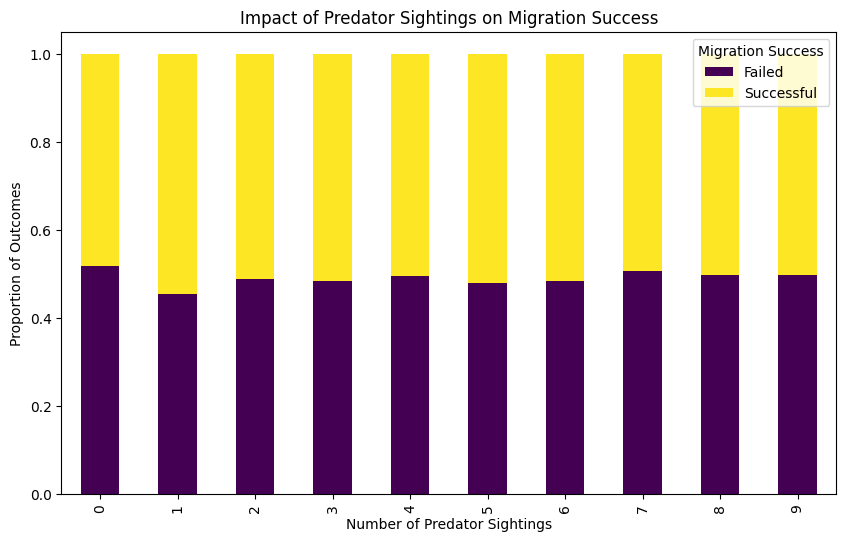

In [162]:
success_by_predators.plot(kind="bar", stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Impact of Predator Sightings on Migration Success")
plt.xlabel("Number of Predator Sightings")
plt.ylabel("Proportion of Outcomes")
plt.legend(["Failed", "Successful"], title="Migration Success")
plt.show()

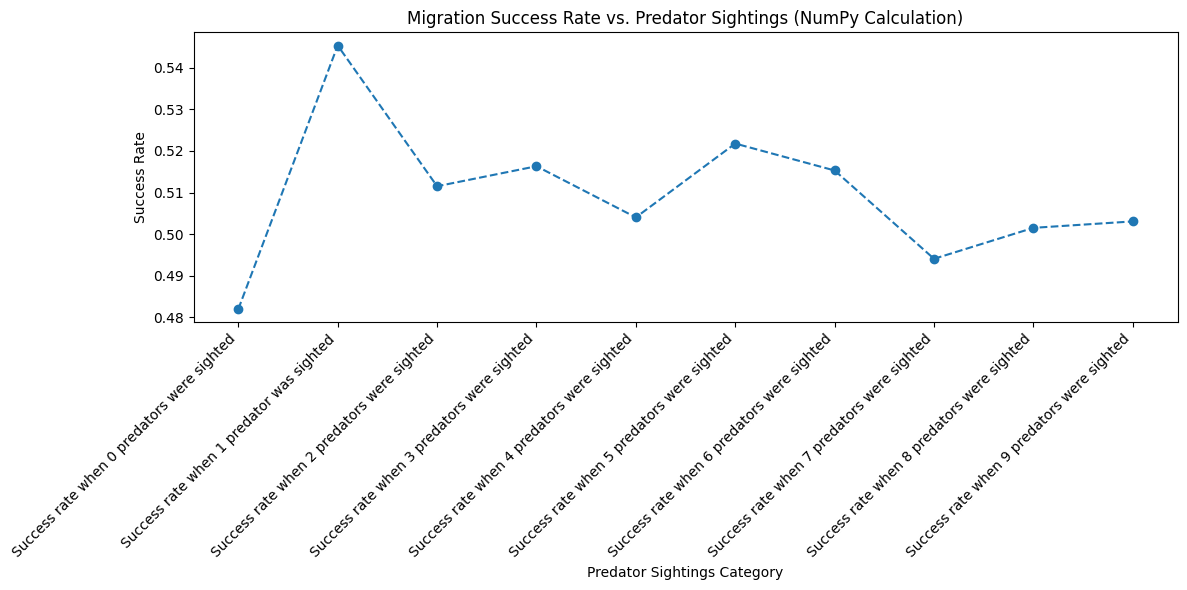

In [166]:
plt.figure(figsize=(12,6))
plt.plot(list(success_rates_numpy.keys()), list(success_rates_numpy.values()), marker="o", linestyle="--")
plt.title("Migration Success Rate vs. Predator Sightings (NumPy Calculation)")
plt.xlabel("Predator Sightings Category")
plt.ylabel("Success Rate")
plt.xticks(rotation=45, ha="right")   # rotate labels to avoid overlap
plt.tight_layout()
plt.show()


Does higher food supply level lead to better migration success?

In [172]:
food_props = (
    data.groupby("Food_Supply_Level")["Migration_Success"]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
)
print("Pandas proportions by food supply level:\n", food_props)


Pandas proportions by food supply level:
 Migration_Success         0         1
Food_Supply_Level                    
High               0.491501  0.508499
Low                0.479248  0.520752
Medium             0.501389  0.498611


In [182]:
food_groups = data.groupby("Food_Supply_Level")

food_rate_numpy = {
    f"Food Supply = {k}": np.mean(v["Migration_Success"].values) for k, v in food_groups
}

print("\nSuccess Rates using NumPy:")
for k, v in food_rate_numpy.items():
    print(f"{k}: {v:.2f}")


Success Rates using NumPy:
Food Supply = High: 0.51
Food Supply = Low: 0.52
Food Supply = Medium: 0.50


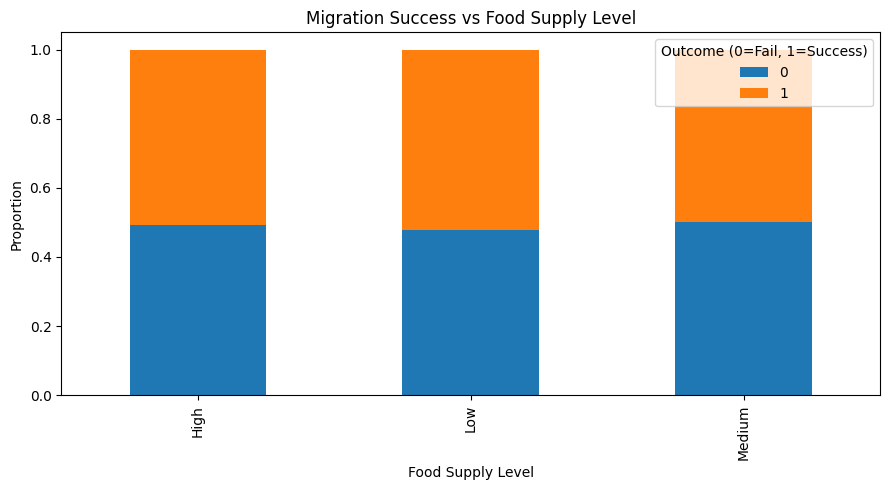

In [177]:
# Visualization - Stacked bar chart
food_props.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Migration Success vs Food Supply Level")
plt.xlabel("Food Supply Level")
plt.ylabel("Proportion")
plt.legend(title="Outcome (0=Fail, 1=Success)")
plt.tight_layout()
plt.show()

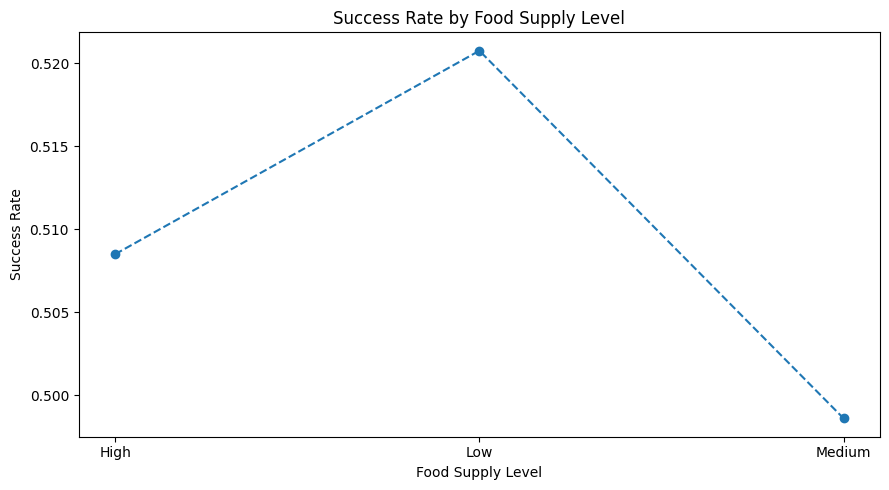

In [178]:
plt.figure(figsize=(9,5))
plt.plot(list(food_rate.index.astype(str)), list(food_rate.values), marker="o", linestyle="--")
plt.title("Success Rate by Food Supply Level")
plt.xlabel("Food Supply Level")
plt.ylabel("Success Rate")
plt.tight_layout()
plt.show()

Does flock size increase the chance of migration success?

In [184]:
flock_props = (
    data.groupby("Flock_Size_Band")["Migration_Success"]
        .value_counts(normalize=True)
        .unstack()
        
)

print("Pandas proportions by flock-size band:\n", flock_props)


Pandas proportions by flock-size band:
 Migration_Success         0         1
Flock_Size_Band                      
Solo (1)           0.562500  0.437500
Small (2–5)        0.477778  0.522222
Medium (6–15)      0.478261  0.521739
Large (16–30)      0.448980  0.551020
Very large (31+)   0.492402  0.507598


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\2429270747.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Flock_Size_Band")["Migration_Success"]


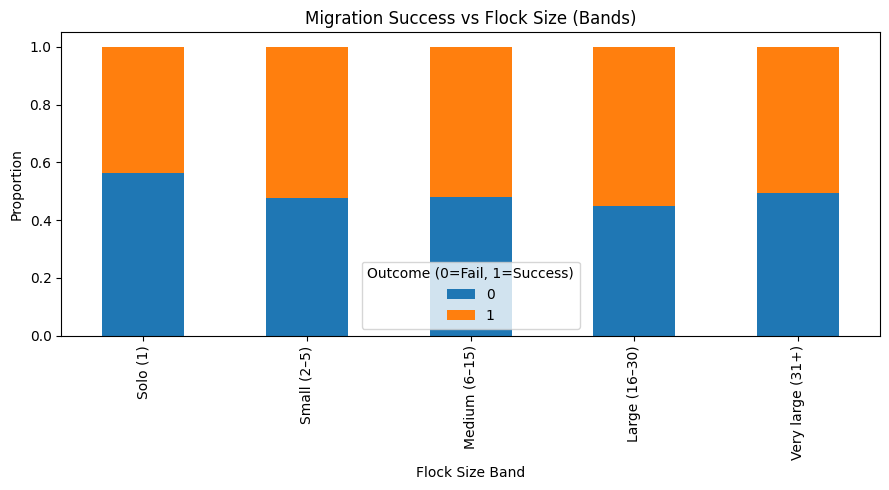

In [185]:
#visualisation - stacked chart 

flock_props.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Migration Success vs Flock Size (Bands)")
plt.xlabel("Flock Size Band")
plt.ylabel("Proportion")
plt.legend(title="Outcome (0=Fail, 1=Success)")
plt.tight_layout()
plt.show()

Which factor among rest stops, predator sightings, flock size, and food supply has the strongest influence on migration success?

In [ ]:
# Select factors
factors = ['Rest_Stops','Predator_Sightings','Flock_Size','Food_Supply_Num']
corr = data[factors + ['Migration_Success']].corr()
print(corr)

                    Rest_Stops  Predator_Sightings  Flock_Size  \
Rest_Stops            1.000000            0.001975    0.015299   
Predator_Sightings    0.001975            1.000000    0.012645   
Flock_Size            0.015299            0.012645    1.000000   
Food_Supply_Num       0.002601            0.000132   -0.011492   
Migration_Success    -0.026734           -0.006273   -0.004159   

                    Food_Supply_Num  Migration_Success  
Rest_Stops                 0.002601          -0.026734  
Predator_Sightings         0.000132          -0.006273  
Flock_Size                -0.011492          -0.004159  
Food_Supply_Num            1.000000          -0.009997  
Migration_Success         -0.009997           1.000000  


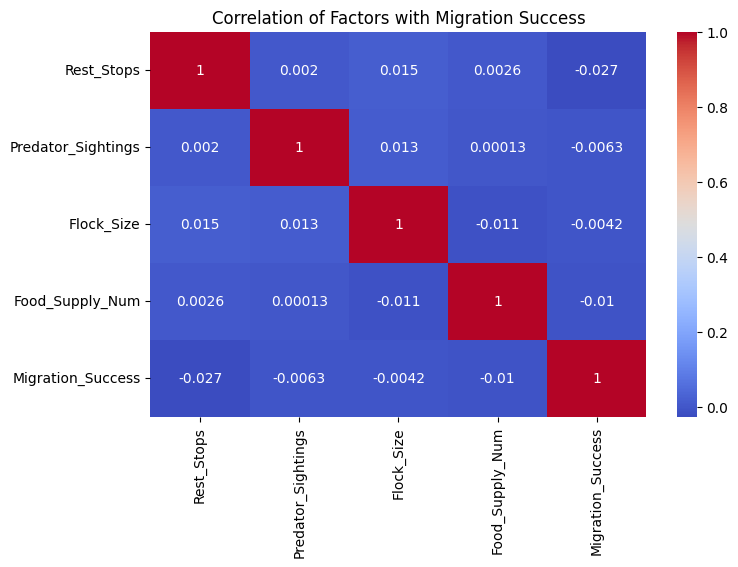

In [201]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Factors with Migration Success")
plt.show()

In [203]:
# Example: Interaction between Food Supply and Flock Size
data["Food_Flock_Interaction"] = data["Food_Supply_Num"] * data["Flock_Size"]

# Correlation with migration success
print(data[["Food_Flock_Interaction", "Migration_Success"]].corr())


                        Food_Flock_Interaction  Migration_Success
Food_Flock_Interaction                1.000000          -0.010867
Migration_Success                    -0.010867           1.000000


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\3600151198.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Food_Supply_Level", "Flock_Size_Band"])["Migration_Success"]


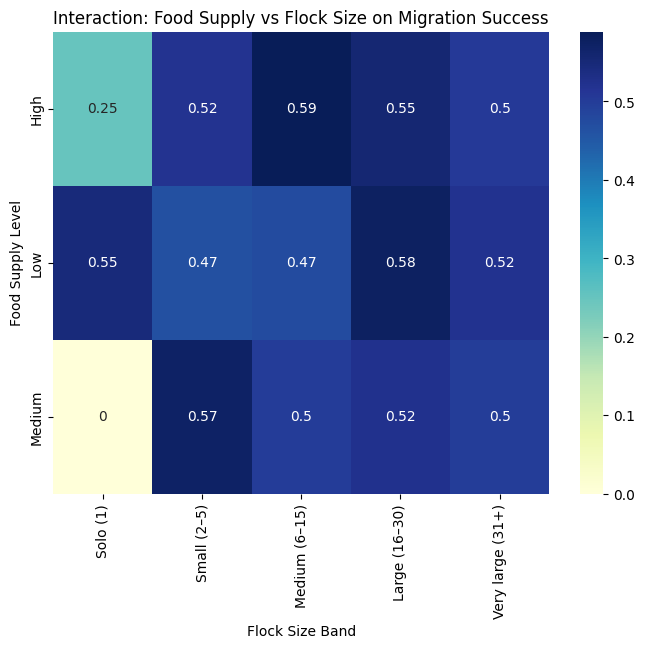

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

interaction_table = (
    data.groupby(["Food_Supply_Level", "Flock_Size_Band"])["Migration_Success"]
        .mean()
        .unstack()
)

plt.figure(figsize=(8,6))
sns.heatmap(interaction_table, annot=True, cmap="YlGnBu", cbar=True)
plt.title("Interaction: Food Supply vs Flock Size on Migration Success")
plt.ylabel("Food Supply Level")
plt.xlabel("Flock Size Band")
plt.show()


In [209]:
#finding correlation 
factors = ['Food_Supply_Num','Flock_Size_Num','Rest_Stops','Predator_Sightings']
corr = data[factors + ['Migration_Success']].corr()

print(corr['Migration_Success'].sort_values(ascending=False))


Migration_Success     1.000000
Predator_Sightings   -0.006273
Flock_Size_Num       -0.007930
Food_Supply_Num      -0.009997
Rest_Stops           -0.026734
Name: Migration_Success, dtype: float64


In [210]:
from scipy.stats import chi2_contingency

for col in ['Food_Supply_Level','Flock_Size_Band']:
    table = pd.crosstab(data[col], data['Migration_Success'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")


Food_Supply_Level: p-value = 0.1972
Flock_Size_Band: p-value = 0.5553


### what are the common migration path for species

In [54]:
import pandas as pd

# Group by species + migration path
path_counts = (
    df.groupby(
        ["Species", "Start_Latitude", "Start_Longitude", "End_Latitude", "End_Longitude"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
)

print("Top 10 Common Migration Paths:")
print(path_counts.head(10))

# If you only want species-wise most common path
common_paths_per_species = (
    path_counts.sort_values(["Species", "Count"], ascending=[True, False])
    .groupby("Species")
    .head(1)   # pick top 1 per species
    .reset_index(drop=True)
)

print("\nMost Common Path for Each Species:")
print(common_paths_per_species)


Top 10 Common Migration Paths:
      Species  Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  \
9983  Warbler       87.491999       -43.796271     27.038294      39.976185   
9982  Warbler       87.345130       -37.250856     23.982432    -163.682889   
9981  Warbler       87.344481        86.826393    -66.839331      74.128222   
9980  Warbler       87.147498       147.759308     46.856143     -36.420687   
9979  Warbler       87.029552       -42.816766     54.558442    -134.028595   
9978  Warbler       87.029313       169.724544     13.952258      33.757012   
9977  Warbler       86.745632       -96.460529     52.396523     137.289859   
9976  Warbler       86.735259       -24.799456     45.884587      29.493390   
9975  Warbler       86.690814       156.851355    -39.991485    -171.723814   
9974  Warbler       86.663180        40.310550     18.762601    -135.981896   

      Count  
9983      1  
9982      1  
9981      1  
9980      1  
9979      1  
9978      1  
9

In [214]:
data.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Flight_Distance_Category',
       'Speed_Category', 'Altitude_Category', 'Temperature_Category',
       'Wind_Speed_Category', 'Visibility_Category', 'Humidity_Category',
       'Flock_Size_Band', 'Food_Supply_Num', 'Food_Flock_Interaction',
       'Flock_Size_Num', 'P

In [213]:
# Create a 'Path' column combining start and end coordinates
data['Path'] = (
    data['Start_Latitude'].astype(str) + "," + data['Start_Longitude'].astype(str) +
    " → " +
    data['End_Latitude'].astype(str) + "," + data['End_Longitude'].astype(str)
)

# Count the frequency of each path per species
path_counts = (
    data.groupby(['Species', 'Path'])
    .size()
    .reset_index(name='Count')
)

# For each species, pick the most common migration path
most_common_paths = (
    path_counts.sort_values(['Species', 'Count'], ascending=[True, False])
    .groupby('Species')
    .head(1)
    .reset_index(drop=True)
)

print("Most common migration paths for each species:\n")
print(most_common_paths)


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\2756840707.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['Species', 'Path'])
C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\2756840707.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Species')


Most common migration paths for each species:

   Species                                               Path  Count
0    Crane  -0.0246360838085593,-44.481967874536 → 35.6544...      1
1    Eagle  -0.1684953119847421,58.543723472433726 → -61.2...      1
2    Goose  -0.0278168786031329,103.9061494769548 → 28.567...      1
3     Hawk  -0.0849987192715531,6.124966979750013 → -67.64...      1
4    Stork  -0.0303925434602376,150.0753051290214 → 74.805...      1
5  Swallow  -0.2072606287278517,-3.322434330900279 → 27.45...      1
6  Warbler  -0.1767899107874484,-128.4281264193197 → 24.11...      1


In [218]:
data['Migration_Success'].value_counts()

Migration_Success
1    5094
0    4906
Name: count, dtype: int64

In [219]:
# Migration success by weather condition
weather_success = (
    data.groupby("Weather_Condition")["Migration_Success"]
    .mean()   # mean of 0/1 gives success rate
    .reset_index(name="Success_Rate")
    .sort_values(by="Success_Rate", ascending=False)
)

print("Success rates by weather condition:\n", weather_success)


Success rates by weather condition:
   Weather_Condition  Success_Rate
3            Stormy      0.526368
0             Clear      0.507532
4             Windy      0.506222
2             Rainy      0.505729
1             Foggy      0.501404


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\1831795762.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Weather_Condition")["Migration_Success"]


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\2138990158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Weather_Condition", y="Success_Rate", data=weather_success, palette="coolwarm")


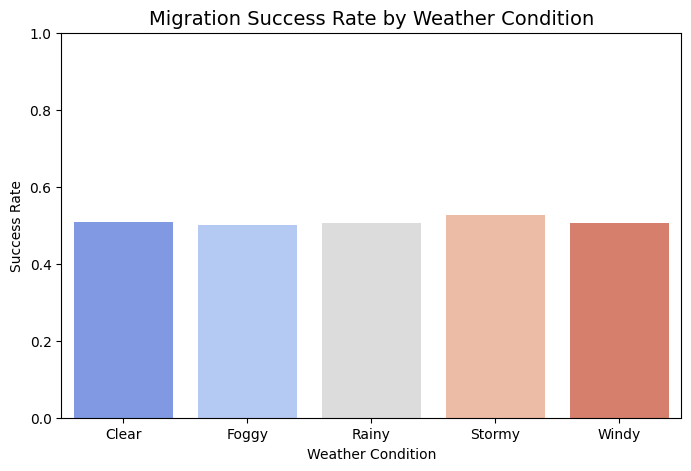

In [220]:
plt.figure(figsize=(8,5))
sns.barplot(x="Weather_Condition", y="Success_Rate", data=weather_success, palette="coolwarm")

plt.title("Migration Success Rate by Weather Condition", fontsize=14)
plt.ylabel("Success Rate")
plt.xlabel("Weather Condition")
plt.ylim(0,1)  # keep scale between 0 and 1
plt.show()

In [ ]:
# Ensure features are numeric (convert categorical/object to numeric if possible)
migration_data = data[features].apply(pd.to_numeric, errors="coerce")

# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(migration_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
migration_data["Cluster"] = kmeans.fit_predict(scaled_data)

# Add cluster info back to main dataframe
data.loc[migration_data.index, "Migration_Behavior_Cluster"] = migration_data["Cluster"]

# Check cluster distribution
print(data["Migration_Behavior_Cluster"].value_counts())

# Cluster summary (only numeric columns now)
cluster_summary = data.groupby("Migration_Behavior_Cluster")[features].mean(numeric_only=True)
print("\nCluster behavior summary:\n", cluster_summary)


Migration_Behavior_Cluster
1.0    3412
0.0    3324
2.0    3264
Name: count, dtype: int64

Cluster behavior summary:
                             Flight_Distance_km  Average_Speed_kmph  \
Migration_Behavior_Cluster                                           
0.0                                2523.287019           50.031971   
1.0                                2498.530003           49.945756   
2.0                                2490.187169           49.881357   

                            Max_Altitude_m  Min_Altitude_m  Rest_Stops  \
Migration_Behavior_Cluster                                               
0.0                            5755.981047      304.247292    7.288809   
1.0                            5504.983587      500.547479    7.422040   
2.0                            5248.835172      699.121324    7.428922   

                            Food_Supply_Num  
Migration_Behavior_Cluster                   
0.0                                1.502407  
1.0                    

In [223]:
# Count species within each cluster
species_cluster = (
    data.groupby(["Migration_Behavior_Cluster", "Species"])
    .size()
    .reset_index(name="Count")
    .sort_values(by=["Migration_Behavior_Cluster", "Count"], ascending=[True, False])
)

print(species_cluster)


    Migration_Behavior_Cluster  Species  Count
2                          0.0    Goose    502
3                          0.0     Hawk    496
6                          0.0  Warbler    487
4                          0.0    Stork    479
0                          0.0    Crane    461
5                          0.0  Swallow    450
1                          0.0    Eagle    449
12                         1.0  Swallow    504
10                         1.0     Hawk    498
8                          1.0    Eagle    493
13                         1.0  Warbler    493
11                         1.0    Stork    480
7                          1.0    Crane    474
9                          1.0    Goose    470
15                         2.0    Eagle    484
18                         2.0    Stork    480
17                         2.0     Hawk    470
19                         2.0  Swallow    469
14                         2.0    Crane    456
16                         2.0    Goose    456
20           

C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\2181673734.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Migration_Behavior_Cluster", "Species"])


In [224]:
# Find dominant cluster for each species
dominant_cluster = (
    species_cluster.loc[
        species_cluster.groupby("Species")["Count"].idxmax()
    ].reset_index(drop=True)
)

print(dominant_cluster)


   Migration_Behavior_Cluster  Species  Count
0                         1.0    Crane    474
1                         1.0    Eagle    493
2                         0.0    Goose    502
3                         1.0     Hawk    498
4                         1.0    Stork    480
5                         1.0  Swallow    504
6                         1.0  Warbler    493


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\1476570886.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_cluster.groupby("Species")["Count"].idxmax()


MIGRATION INTERRUPTED

In [228]:
data['Migration_Interrupted'].value_counts()

Migration_Interrupted
Yes    5031
No     4969
Name: count, dtype: int64

In [234]:
num_features = ["Flight_Distance_km", "Average_Speed_kmph", 
                "Max_Altitude_m", "Min_Altitude_m", 
                "Rest_Stops", "Food_Supply_Num"]

summary = data.groupby("Migration_Interrupted")[num_features].mean()
print("\nMean values by Migration_Interrupted:\n", summary)


Mean values by Migration_Interrupted:
                        Flight_Distance_km  Average_Speed_kmph  Max_Altitude_m  \
Migration_Interrupted                                                           
No                            2496.400320           49.958762     5544.955524   
Yes                           2511.577847           49.948092     5465.155834   

                       Min_Altitude_m  Rest_Stops  Food_Supply_Num  
Migration_Interrupted                                               
No                         503.162809    7.327229         2.020527  
Yes                        497.098390    7.432121         1.992248  


In [ ]:
# Compare weather condition
weather_interrupt = (
    data.groupby(["Weather_Condition", "Migration_Interrupted"])
    .size()
    .unstack(fill_value=0)
)
print("\nWeather vs Migration Interrupted:\n", weather_interrupt)


Weather vs Migration Interrupted:
 Migration_Interrupted    No   Yes
Weather_Condition                
Clear                   956   969
Foggy                  1062  1074
Rainy                   957   963
Stormy                  999  1011
Windy                   995  1014


C:\Users\Leo Samuel Gilbert\AppData\Local\Temp\ipykernel_51884\583540578.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Weather_Condition", "Migration_Interrupted"])


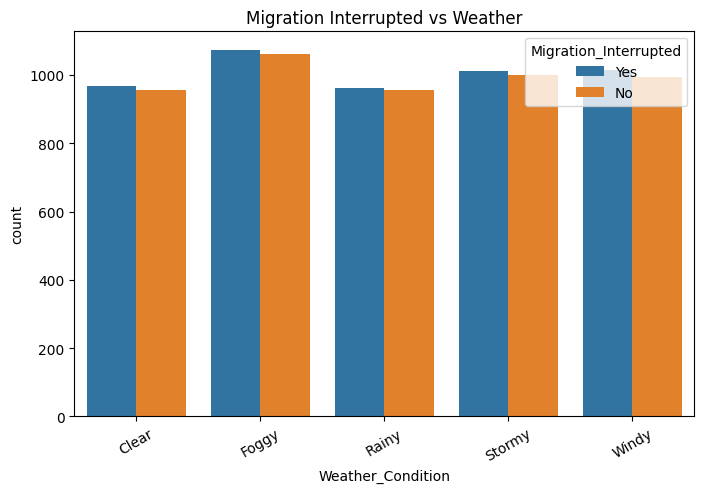

In [231]:
plt.figure(figsize=(8,5))
sns.countplot(x="Weather_Condition", hue="Migration_Interrupted", data=data)
plt.title("Migration Interrupted vs Weather")
plt.xticks(rotation=30)
plt.show()

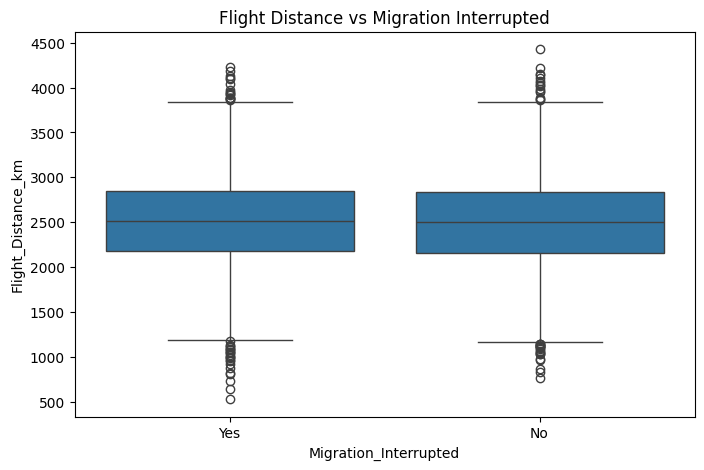

In [232]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Migration_Interrupted", y="Flight_Distance_km", data=data)
plt.title("Flight Distance vs Migration Interrupted")
plt.show()

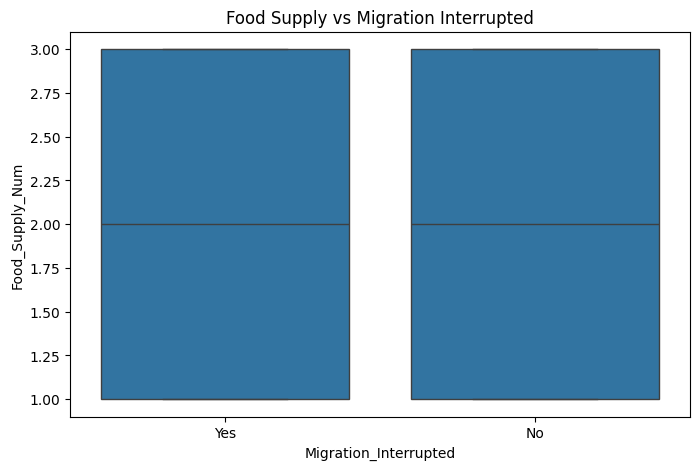

In [233]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Migration_Interrupted", y="Food_Supply_Num", data=data)
plt.title("Food Supply vs Migration Interrupted")
plt.show()

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure target variable is numeric 0/1
if data['Migration_Success'].dtype == 'O':
    data['Migration_Success'] = (
        data['Migration_Success'].str.strip().str.lower().map({'yes':1,'no':0})
    )

# Helpful z-score function (NumPy-only)
def zscore(a):
    a = np.asarray(a, dtype=float)
    mu = np.nanmean(a)
    sd = np.nanstd(a)
    return (a - mu) / (sd if sd > 0 else 1.0)


   Species  mean_distance_km  mean_speed_kmph  success_rate     n
4    Stork       2535.598807        50.031480           NaN  1439
1    Eagle       2514.924476        49.914116           NaN  1426
3     Hawk       2514.236377        49.859891           NaN  1464
5  Swallow       2500.140144        49.987723           NaN  1423
6  Warbler       2498.570841        50.075535           NaN  1429
2    Goose       2496.170635        50.015525           NaN  1428
0    Crane       2468.451377        49.786909           NaN  1391


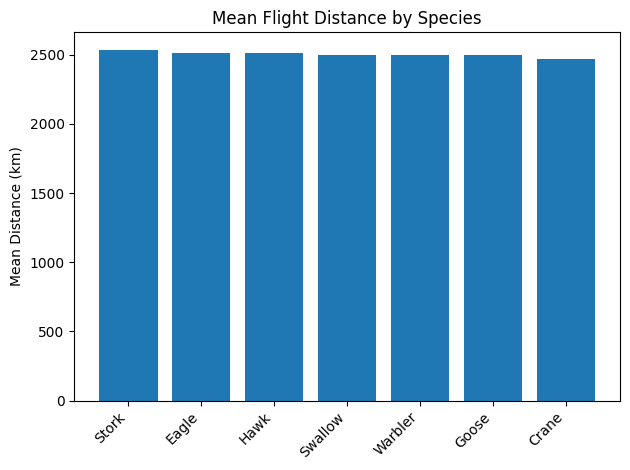

          Region  success_rate  mean_distance_km     n
0         Africa           NaN       2491.585821  1669
1           Asia           NaN       2523.910579  1687
2      Australia           NaN       2496.964227  1633
3         Europe           NaN       2512.058681  1595
4  North America           NaN       2516.127757  1699
5  South America           NaN       2484.964828  1717


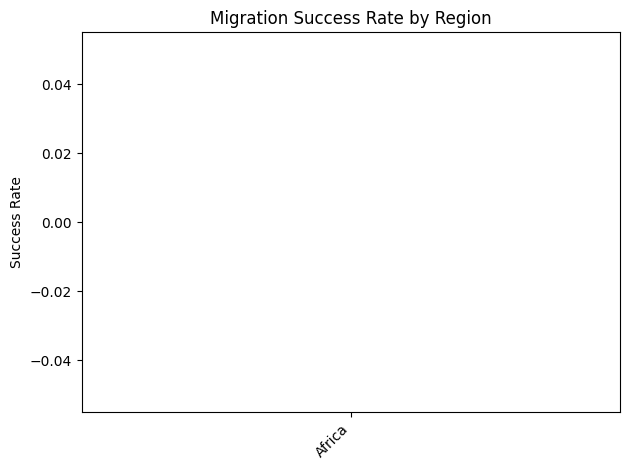

  Migration_Start_Month  count
0                   Apr   1215
1                   Feb   1252
2                   Jan   1273
3                   Mar   1297
4                   May   1239
5                   Nov   1273
6                   Oct   1262
7                   Sep   1189


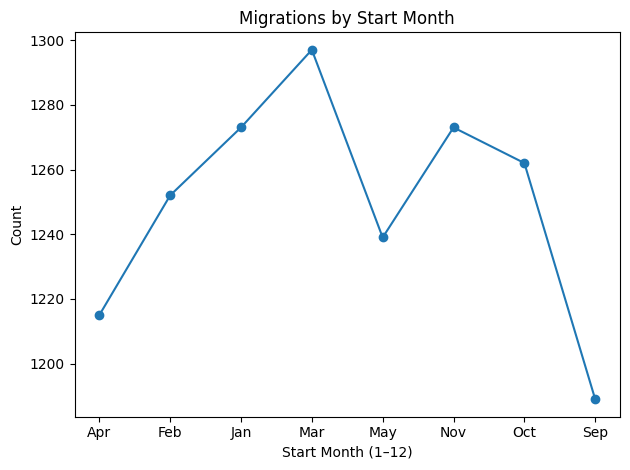

In [58]:
# --- Species-wise trends
species_stats = (data
    .groupby('Species', as_index=False)
    .agg(mean_distance_km=('Flight_Distance_km','mean'),
         mean_speed_kmph=('Average_Speed_kmph','mean'),
         success_rate=('Migration_Success','mean'),
         n=('Bird_ID','count'))
    .sort_values('mean_distance_km', ascending=False))
print(species_stats.head(10))

plt.figure()
plt.bar(species_stats['Species'], species_stats['mean_distance_km'])
plt.title("Mean Flight Distance by Species")
plt.ylabel("Mean Distance (km)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# --- Region-wise success and effort
region_stats = (data
    .groupby('Region', as_index=False)
    .agg(success_rate=('Migration_Success','mean'),
         mean_distance_km=('Flight_Distance_km','mean'),
         n=('Bird_ID','count'))
    .sort_values('success_rate', ascending=False))
print(region_stats)

plt.figure()
plt.bar(region_stats['Region'], region_stats['success_rate'])
plt.title("Migration Success Rate by Region")
plt.ylabel("Success Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()




  Migration_Start_Month  count
0                   Apr   1215
1                   Feb   1252
2                   Jan   1273
3                   Mar   1297
4                   May   1239
5                   Nov   1273
6                   Oct   1262
7                   Sep   1189


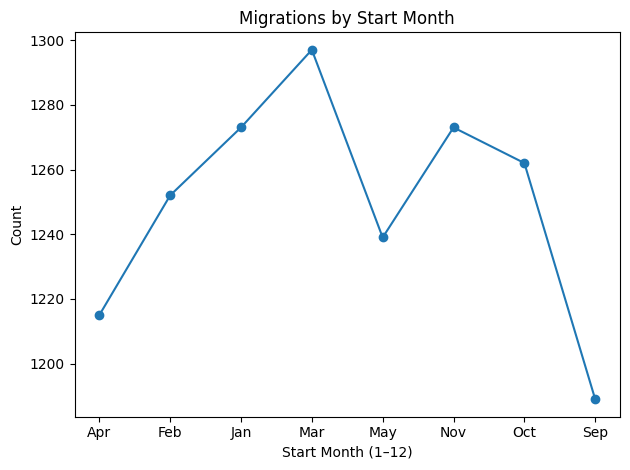

In [60]:
#Seasonal patterns 
month_counts = (data
    .groupby('Migration_Start_Month', as_index=False)
    .size().rename(columns={'size':'count'})
    .sort_values('Migration_Start_Month'))
print(month_counts)

plt.figure()
plt.plot(month_counts['Migration_Start_Month'], month_counts['count'], marker='o')
plt.title("Migrations by Start Month")
plt.xlabel("Start Month (1–12)")
plt.ylabel("Count")
plt.tight_layout(); plt.show()

## Reasons for bird migrations 

In [62]:
reason_counts = data['Migration_Reason'].value_counts()

print("Overall Migration Reasons:\n")
print(reason_counts)

# comparing migration reason by species
reason_by_species = df.groupby(['Species', 'Migration_Reason']).size().unstack(fill_value=0)

print("\nMigration Reasons by Species:\n")
print(reason_by_species)



Overall Migration Reasons:

Migration_Reason
Feeding            2573
Avoid Predators    2518
Climate Change     2473
Breeding           2436
Name: count, dtype: int64

Migration Reasons by Species:

Migration_Reason  Avoid Predators  Breeding  Climate Change  Feeding
Species                                                             
Crane                         324       350             359      358
Eagle                         349       345             362      370
Goose                         390       310             348      380
Hawk                          371       335             390      368
Stork                         385       390             318      346
Swallow                       351       372             354      346
Warbler                       348       334             342      405


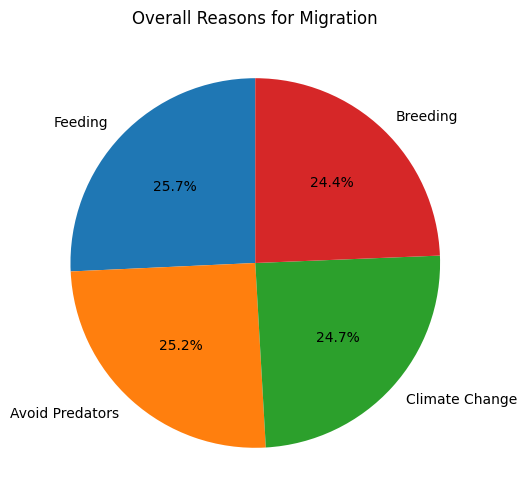

In [64]:
# Visualization - Pie chart for overall reasons
plt.figure(figsize=(6,6))
plt.pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Overall Reasons for Migration")
plt.show()

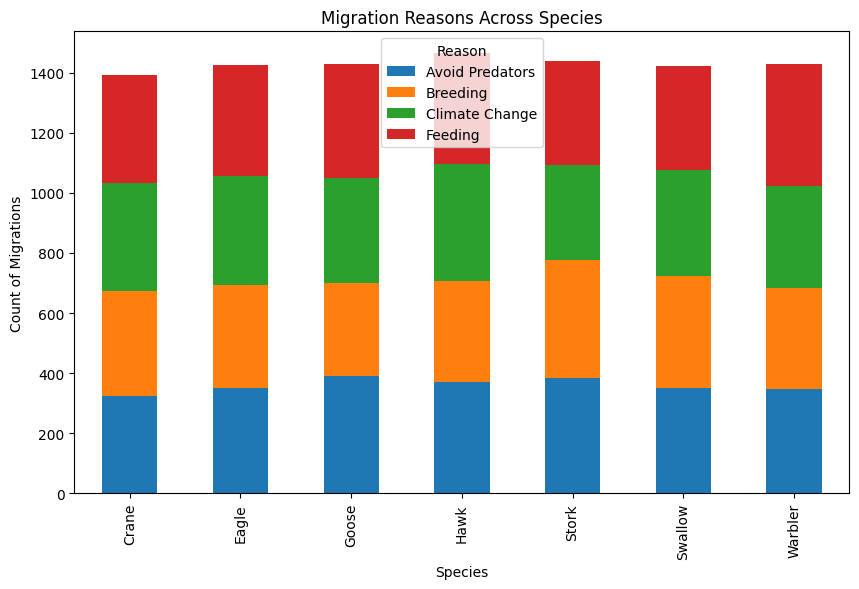

In [66]:
# Visualization - Bar chart by species
reason_by_species.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Migration Reasons Across Species")
plt.xlabel("Species")
plt.ylabel("Count of Migrations")
plt.legend(title="Reason")
plt.show()

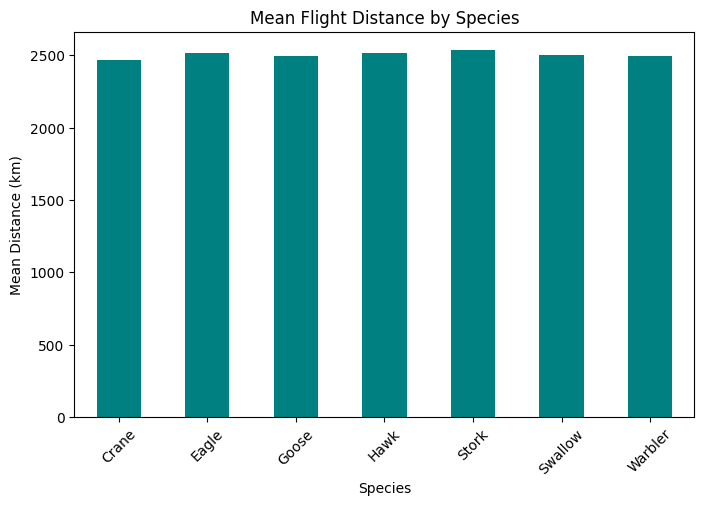

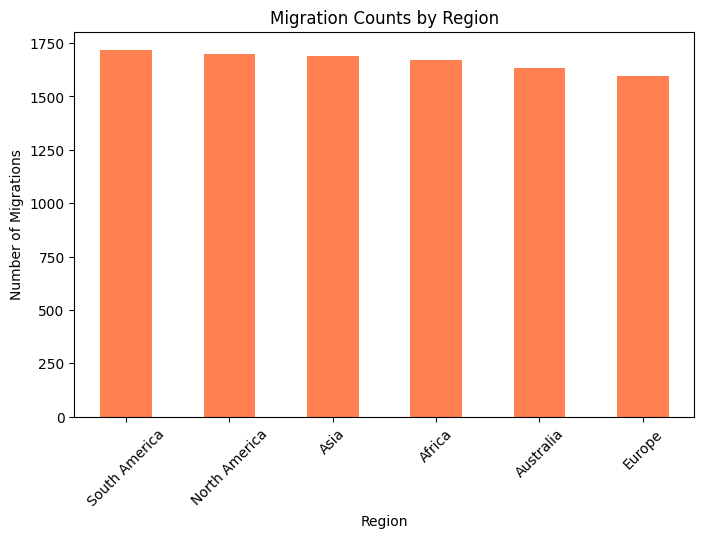

KeyError: 'Season'

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming your dataset is loaded as df
# Example: df = pd.read_csv("bird_migration.csv")

# 1. Mean Flight Distance by Species
species_distance = df.groupby("Species")["Flight_Distance_km"].mean()
species_distance.plot(kind="bar", figsize=(8,5), color="teal")
plt.ylabel("Mean Distance (km)")
plt.title("Mean Flight Distance by Species")
plt.xticks(rotation=45)
plt.show()

# 2. Migration Counts by Region
region_counts = df["Region"].value_counts()
region_counts.plot(kind="bar", figsize=(8,5), color="coral")
plt.ylabel("Number of Migrations")
plt.title("Migration Counts by Region")
plt.xticks(rotation=45)
plt.show()

# 3. Seasonal Migration Trends
season_distance = df.groupby("Season")["Flight_Distance_km"].mean()
season_distance.plot(kind="bar", figsize=(8,5), color="navy")
plt.ylabel("Mean Distance (km)")
plt.title("Seasonal Migration Trends")
plt.xticks(rotation=45)
plt.show()


## Weather and speed, 

In [84]:
weather_speed_corr = data[['Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Flight_Distance_km']].corr()
print(weather_speed_corr)

                    Temperature_C  Wind_Speed_kmph  Humidity_%  \
Temperature_C            1.000000         0.007708   -0.012315   
Wind_Speed_kmph          0.007708         1.000000   -0.014123   
Humidity_%              -0.012315        -0.014123    1.000000   
Flight_Distance_km      -0.000570        -0.017460   -0.001048   

                    Flight_Distance_km  
Temperature_C                -0.000570  
Wind_Speed_kmph              -0.017460  
Humidity_%                   -0.001048  
Flight_Distance_km            1.000000  


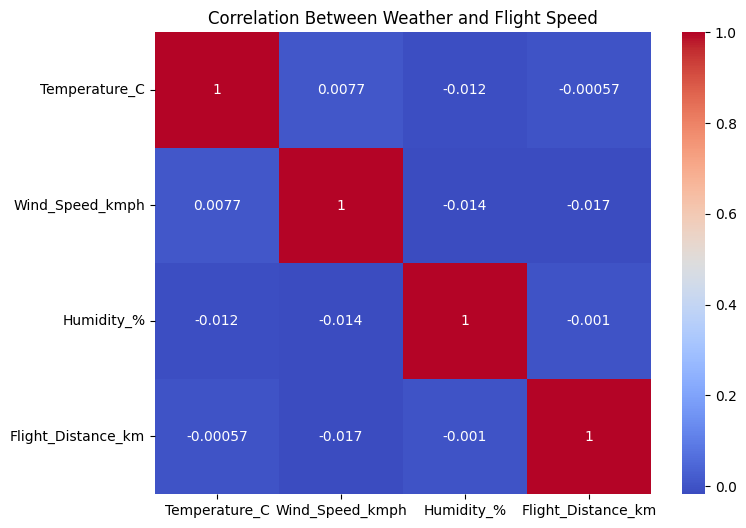

In [85]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(weather_speed_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather and Flight Speed')
plt.show()

In [67]:
weather_flight_corr = data[['Temperature_C',
                            'Wind_Speed_kmph',
                            'Humidity_%',
                            'Flight_Distance_km',
                            'Average_Speed_kmph']].corr()

print("Correlation between Weather and Flight Performance:")
print(weather_flight_corr[['Flight_Distance_km', 'Average_Speed_kmph']])

# Relationship between weather and nesting success (breeding migrations)
nesting_weather = data[data['Migration_Reason'] == 'Breeding'][['Temperature_C',
                                                                'Wind_Speed_kmph',
                                                                'Humidity_%']].mean()

print("\nAverage Weather Conditions during Breeding (Nesting Success):")
print(nesting_weather)

Correlation between Weather and Flight Performance:
                    Flight_Distance_km  Average_Speed_kmph
Temperature_C                -0.000844           -0.000084
Wind_Speed_kmph              -0.016871           -0.002530
Humidity_%                   -0.001839            0.004506
Flight_Distance_km            1.000000           -0.009993
Average_Speed_kmph           -0.009993            1.000000

Average Weather Conditions during Breeding (Nesting Success):
Temperature_C      12.602340
Wind_Speed_kmph    30.155090
Humidity_%         53.837849
dtype: float64


In [91]:
data.columns

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude',
       'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph',
       'Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph',
       'Humidity_%', 'Pressure_hPa', 'Visibility_km', 'Nesting_Success',
       'Tag_Battery_Level_%', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Migrated_in_Flock', 'Flock_Size',
       'Food_Supply_Level', 'Tracking_Quality', 'Migration_Interrupted',
       'Interrupted_Reason', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Origin', 'Flight_Distance_Category',
       'Speed_Category', 'Altitude_Category', 'Temperature_Category',
       'Wind_Speed_Category', 'Visibility_Category', 'Humidity_Category'],
      dtype='object')

## weather Vs migration success 

In [78]:
print(data['Migration_Success'].values)

[nan nan nan ... nan nan nan]


In [69]:
env_factors_corr = data[['Temperature_C',
                         'Wind_Speed_kmph',
                         'Humidity_%',
                         'Max_Altitude_m',
                         'Min_Altitude_m',
                         'Flight_Distance_km',
                         'Migration_Success']].corr()

print("Correlation between Environmental Factors and Migration Success:")
print(env_factors_corr['Migration_Success'])

Correlation between Environmental Factors and Migration Success:
Temperature_C        NaN
Wind_Speed_kmph      NaN
Humidity_%           NaN
Max_Altitude_m       NaN
Min_Altitude_m       NaN
Flight_Distance_km   NaN
Migration_Success    NaN
Name: Migration_Success, dtype: float64


In [93]:
altitude_interruptions_corr = data[['Max_Altitude_m', 'Min_Altitude_m', 'Migration_Interrupted']].corr()
print(altitude_interruptions_corr)

ValueError: could not convert string to float: 'Yes'

In [95]:
#Question: What are the migration patterns for different bird species?
species_migration = data.groupby('Species')[['Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m']].mean().reset_index()
print(species_migration)


   Species  Flight_Distance_km  Average_Speed_kmph  Max_Altitude_m
0    Crane         2467.412983           49.786909     5444.657081
1    Eagle         2514.805098           49.914116     5535.745442
2    Goose         2496.023130           50.015525     5479.738095
3     Hawk         2512.792589           49.859891     5573.135246
4    Stork         2536.632787           50.031480     5574.164698
5  Swallow         2500.581933           49.987723     5439.527758
6  Warbler         2498.590455           50.075535     5482.704689


C:\Users\LSGILBE\AppData\Local\Temp\ipykernel_23780\3453437582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=species_migration, x='Species', y='Flight_Distance_km', palette='viridis')


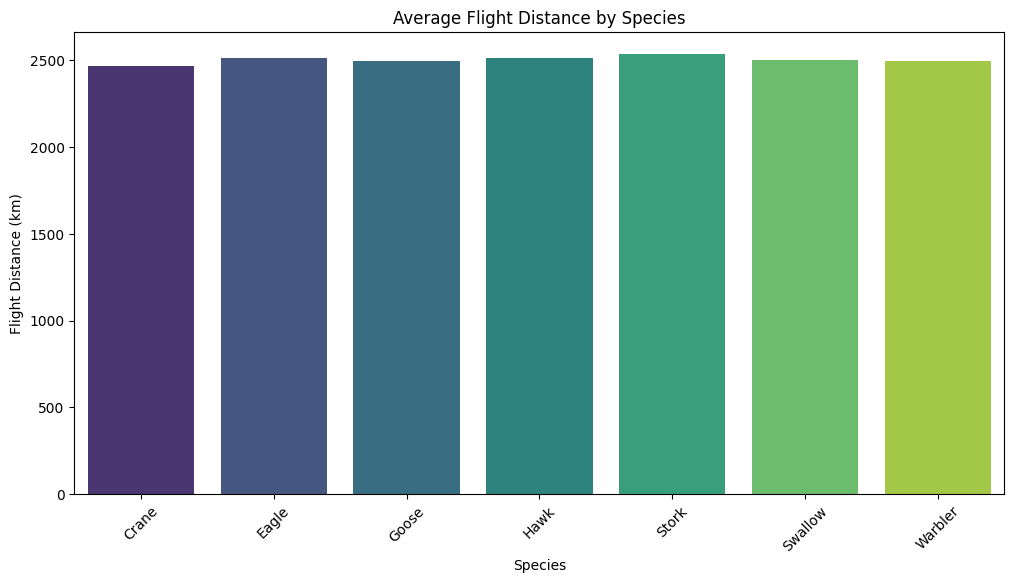

In [96]:
# Visualize migration patterns by species
plt.figure(figsize=(12, 6))
sns.barplot(data=species_migration, x='Species', y='Flight_Distance_km', palette='viridis')
plt.title('Average Flight Distance by Species')
plt.xlabel('Species')
plt.ylabel('Flight Distance (km)')
plt.xticks(rotation=45)
plt.show()

Migration_Success    Failed  Successful
Weather_Condition                      
Clear              0.492468    0.507532
Foggy              0.498596    0.501404
Rainy              0.494271    0.505729
Stormy             0.473632    0.526368
Windy              0.493778    0.506222


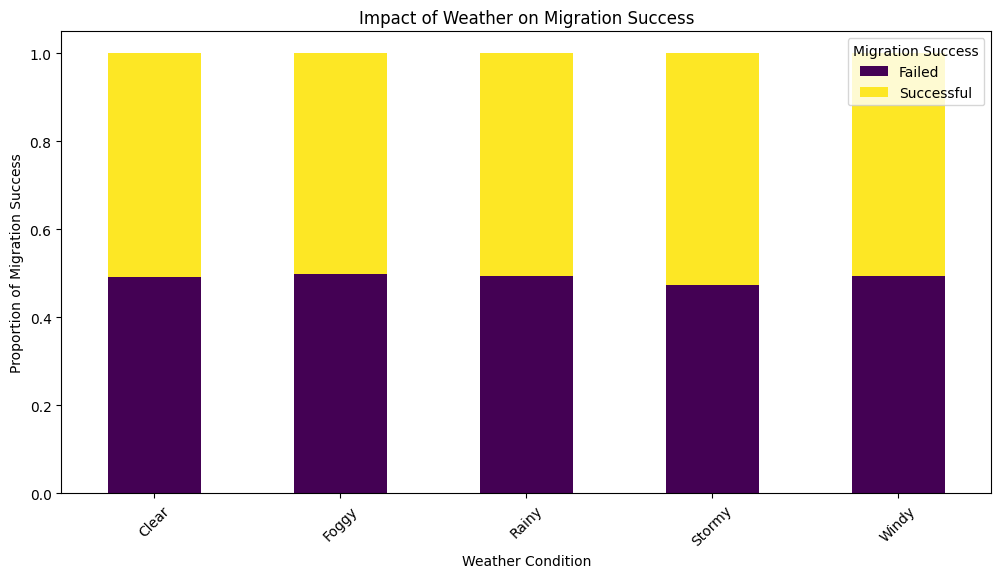

In [97]:
#Question: How does weather impact migration success and interruptions?
weather_success = data.groupby('Weather_Condition')['Migration_Success'].value_counts(normalize=True).unstack()
print(weather_success)

# Visualize migration success by weather condition
weather_success.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Impact of Weather on Migration Success')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Migration Success')
plt.legend(title='Migration Success', loc='upper right')
plt.xticks(rotation=45)
plt.show()


Migration_Interrupted        No       Yes
Weather_Condition                        
Clear                  0.496623  0.503377
Foggy                  0.497191  0.502809
Rainy                  0.498437  0.501563
Stormy                 0.497015  0.502985
Windy                  0.495271  0.504729


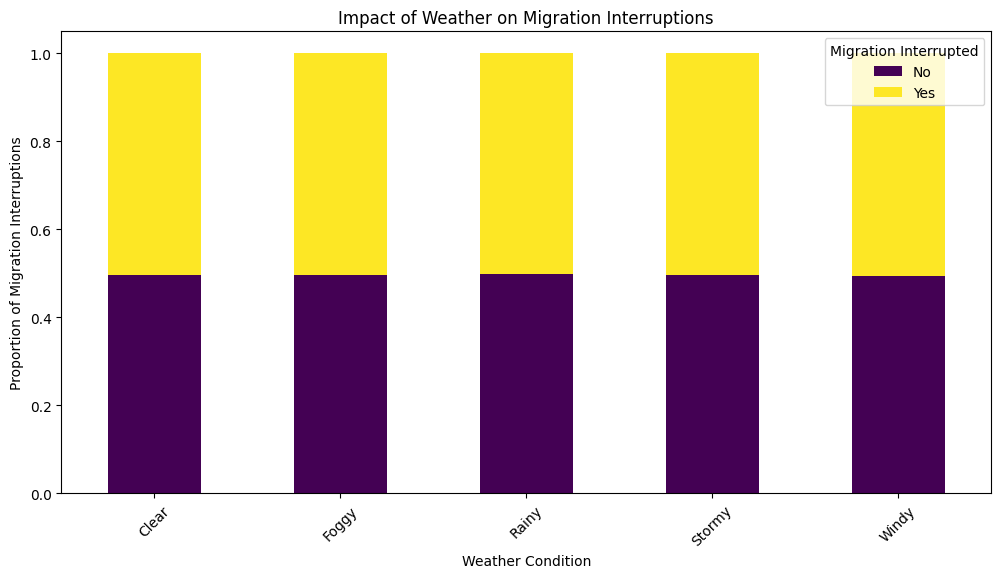

In [98]:
weather_interruptions = data.groupby('Weather_Condition')['Migration_Interrupted'].value_counts(normalize=True).unstack()
print(weather_interruptions)

# Visualize migration interruptions by weather condition
weather_interruptions.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Impact of Weather on Migration Interruptions')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Migration Interruptions')
plt.legend(title='Migration Interrupted', loc='upper right')
plt.xticks(rotation=45)
plt.show()

  Month  Count
0   Mar   1297
1   Jan   1273
2   Nov   1273
3   Oct   1262
4   Feb   1252
5   May   1239
6   Apr   1215
7   Sep   1189


C:\Users\LSGILBE\AppData\Local\Temp\ipykernel_23780\3522240656.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=migration_activity, x='Month', y='Count', palette='viridis')


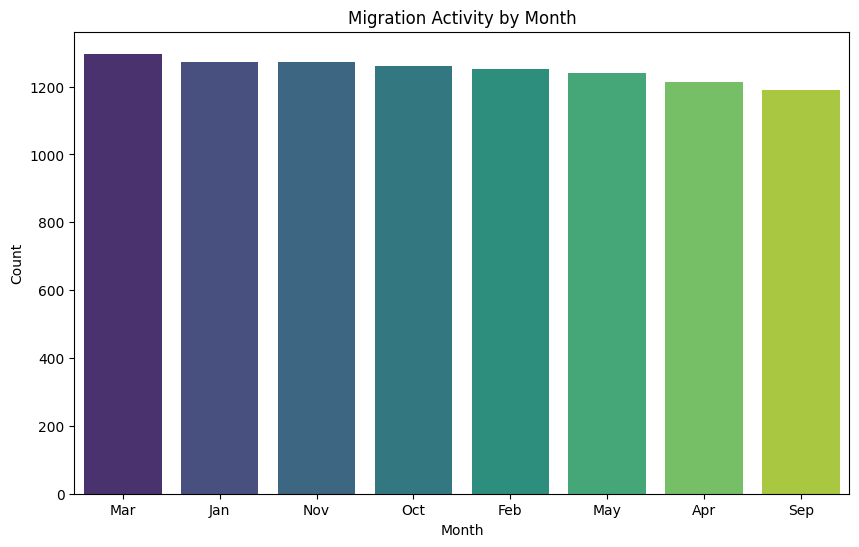

In [99]:
#Question: Which months see the highest migration activity?
migration_activity = data['Migration_Start_Month'].value_counts().reset_index()
migration_activity.columns = ['Month', 'Count']
print(migration_activity)

# Visualize migration activity by month
plt.figure(figsize=(10, 6))
sns.barplot(data=migration_activity, x='Month', y='Count', palette='viridis')
plt.title('Migration Activity by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

      Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  Count
0         -89.999003       116.802571    -54.380507     151.063906      1
6670       29.153523        24.302352    -78.001126      55.105593      1
6663       28.918140       131.663227     84.862021     164.121040      1
6664       28.928328       -41.482004    -51.356007      16.128116      1
6665       28.975128       -90.409108    -43.965531      76.150803      1


C:\Users\LSGILBE\AppData\Local\Temp\ipykernel_23780\3031518218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=migration_paths.head(10), x='Count', y='Start_Latitude', palette='viridis')


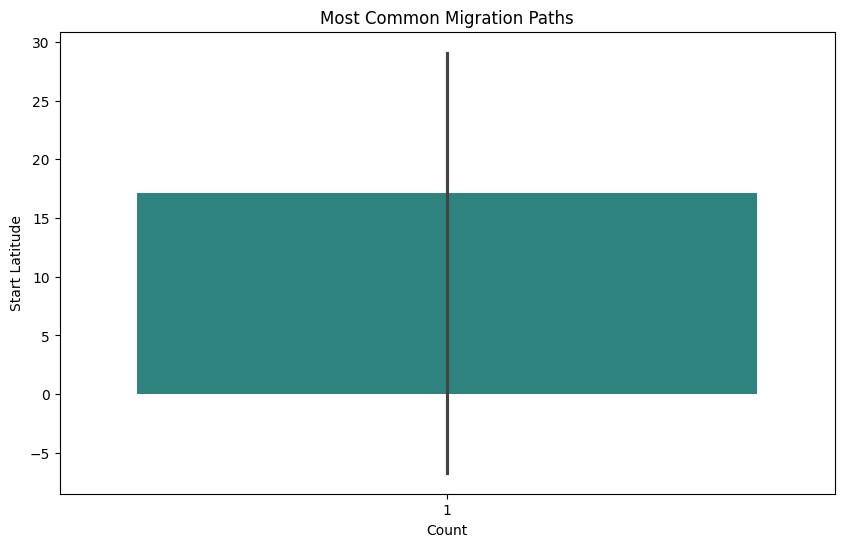

In [101]:
#Question: What are the most common migration paths for birds?

# Group by start and end locations to find common paths
migration_paths = data.groupby(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude']).size().reset_index(name='Count')
migration_paths = migration_paths.sort_values(by='Count', ascending=False)
print(migration_paths.head())

# Visualize the most common migration paths
plt.figure(figsize=(10, 6))
sns.barplot(data=migration_paths.head(10), x='Count', y='Start_Latitude', palette='viridis')
plt.title('Most Common Migration Paths')
plt.xlabel('Count')
plt.ylabel('Start Latitude')
plt.show()

In [126]:
#Question: Are there correlations between altitude, weather, and migration outcomes?
# Correlation matrix for relevant columns
correlation_matrix = data[['Max_Altitude_m', 'Min_Altitude_m', 'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Migration_Success']].corr()
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


ValueError: could not convert string to float: 'Failed'

In [128]:
data.dtypes

Species                     object
Region                      object
Habitat                     object
Weather_Condition           object
Migration_Reason            object
Start_Latitude             float64
Start_Longitude            float64
End_Latitude               float64
End_Longitude              float64
Flight_Distance_km         float64
Flight_Duration_hours      float64
Average_Speed_kmph         float64
Max_Altitude_m               int64
Min_Altitude_m               int64
Temperature_C              float64
Wind_Speed_kmph            float64
Humidity_%                   int64
Pressure_hPa               float64
Visibility_km              float64
Nesting_Success             object
Tag_Battery_Level_%          int64
Migration_Start_Month       object
Migration_End_Month         object
Rest_Stops                   int64
Predator_Sightings           int64
Migrated_in_Flock           object
Flock_Size                   int64
Food_Supply_Level           object
Tracking_Quality    

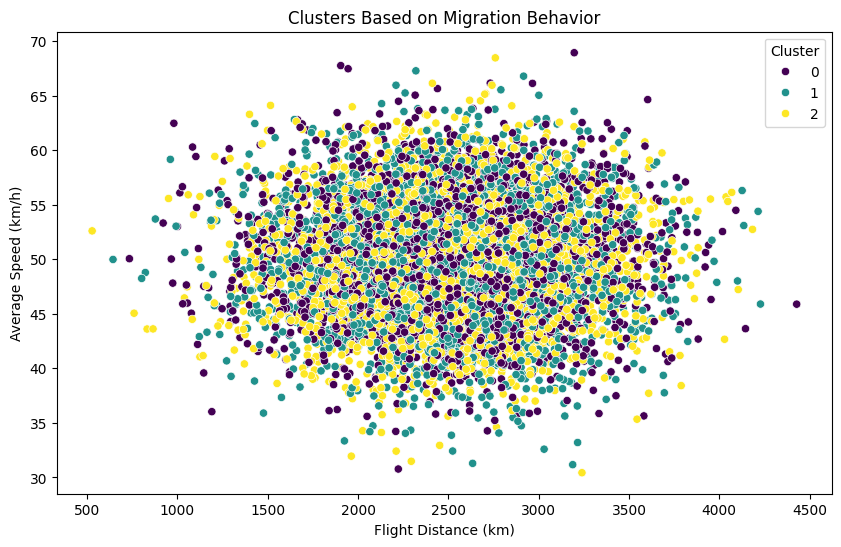

In [104]:
#Can birds be grouped into clusters based on their migration behavior?

from sklearn.cluster import KMeans

# Select features for clustering
clustering_features = ['Flight_Distance_km', 'Average_Speed_kmph', 'Max_Altitude_m']
X = data[clustering_features]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Flight_Distance_km', y='Average_Speed_kmph', hue='Cluster', palette='viridis')
plt.title('Clusters Based on Migration Behavior')
plt.xlabel('Flight Distance (km)')
plt.ylabel('Average Speed (km/h)')
plt.show()

In [105]:
#Question: Can migration success be predicted based on weather, altitude, and speed?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prepare data for predictive modeling
features = ['Temperature_C', 'Wind_Speed_kmph', 'Max_Altitude_m', 'Average_Speed_kmph']
target = 'Migration_Success'

# Encode target variable
data[target] = data[target].map({'Yes': 1, 'No': 0})

# Split data into train and test sets
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Predicting Migration Success')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

ValueError: Input y contains NaN.

In [106]:
#Question: Do larger flocks have higher migration success rates?
# Group by flock size and calculate migration success rate
flock_success = data.groupby('Flock_Size')['Migration_Success'].value_counts(normalize=True).unstack()
print(flock_success)

# Visualize migration success by flock size
flock_success.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Migration Success by Flock Size')
plt.xlabel('Flock Size')
plt.ylabel('Proportion of Migration Success')
plt.legend(title='Migration Success', loc='upper right')
plt.show()

Empty DataFrame
Columns: []
Index: []


TypeError: no numeric data to plot

           Region Migration_Start_Month  Flight_Distance_km
0          Africa                   Apr         2441.386243
1          Africa                   Feb         2515.800683
2          Africa                   Jan         2488.484063
3          Africa                   Mar         2456.335607
4          Africa                   May         2477.814866
5          Africa                   Nov         2554.800280
6          Africa                   Oct         2483.768000
7          Africa                   Sep         2513.637354
8            Asia                   Apr         2512.532098
9            Asia                   Feb         2518.757463
10           Asia                   Jan         2543.655087
11           Asia                   Mar         2549.939265
12           Asia                   May         2536.741818
13           Asia                   Nov         2519.378364
14           Asia                   Oct         2510.429189
15           Asia                   Sep 

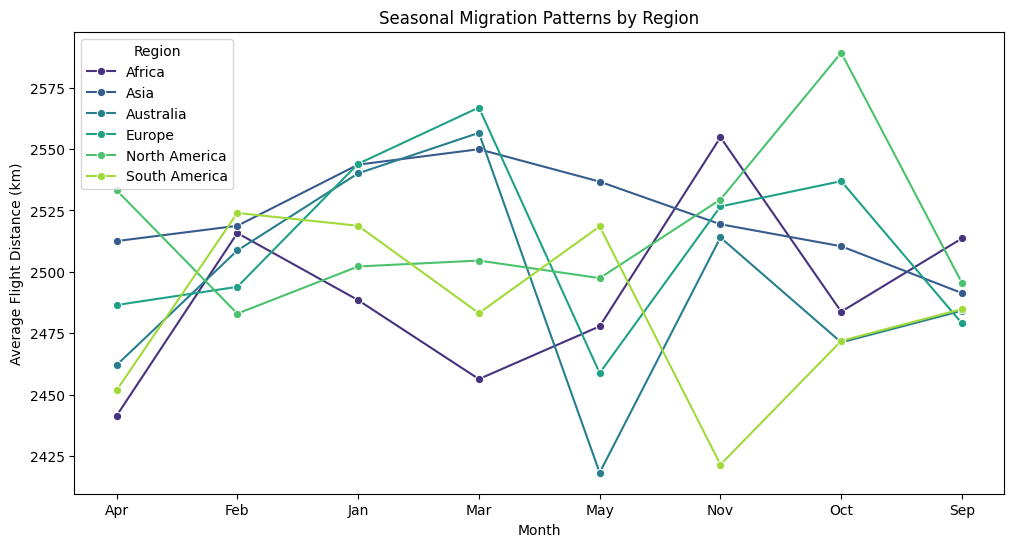

In [107]:
#Question: How do migration patterns vary across seasons and regions?
# Group by region and start month to calculate average flight distance
regional_seasonal_patterns = data.groupby(['Region', 'Migration_Start_Month'])['Flight_Distance_km'].mean().reset_index()
print(regional_seasonal_patterns)

# Visualize seasonal migration patterns by region
plt.figure(figsize=(12, 6))
sns.lineplot(data=regional_seasonal_patterns, x='Migration_Start_Month', y='Flight_Distance_km', hue='Region', marker='o', palette='viridis')
plt.title('Seasonal Migration Patterns by Region')
plt.xlabel('Month')
plt.ylabel('Average Flight Distance (km)')
plt.show()